# Preprocessing Overview

## Model Pipeline

This notebook prepares data for a **two-stage model pipeline**:

1. **Classification model** — predicts whether a signal is LOS (0) or NLOS (1)
2. **Regression model** — predicts the true range (distance), using the classifier's NLOS prediction as an additional input feature

The classifier runs first; its output is appended to the feature set before passing into the regressor.

---

## Dataset Splits

### Classification
| Variable | Shape | Description |
|---|---|---|
| `X_train_classification` | (33,600 × 99) | Training features: scaled non-CIR signal features + 86 PCA components of CIR |
| `X_test_classification` | (8,400 × 99) | Test features: same transformation applied to held-out data |
| `y_train` | (33,600,) | Training labels — NLOS binary flag (0 = LOS, 1 = NLOS) |
| `y_test` | (8,400,) | Test labels — NLOS binary flag |

### Regression
| Variable | Shape | Description |
|---|---|---|
| `X_train_reg` | (33,600 × 100) | `X_train_classification` + true NLOS label appended as an extra feature |
| `X_test_reg` | (8,400 × 100) | `X_test_classification` + true NLOS label appended as an extra feature |
| `y_reg_train` | (33,600,) | Training targets — measured range in metres |
| `y_reg_test` | (8,400,) | Test targets — measured range in metres |

> **80/20 train-test split**, stratified on the NLOS label to preserve class balance.

In [1]:
# Preprocessing pipeline (copied from preprocessing.ipynb)

import numpy as np
import pandas as pd
import uwb_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------------------------
# Load raw data and construct DataFrame with same columns
# ---------------------------------------------------------------------------
data = uwb_dataset.import_from_files()  # numpy array

base_cols = [
    "NLOS","RANGE","FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","CIR_PWR","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR"
 ]
cir_cols = [f"CIR{i}" for i in range(1016)]
cols = base_cols + cir_cols

df = pd.DataFrame(data, columns=cols)

# ---------------------------------------------------------------------------
# Window CIR around the detected first path index (FP_IDX)
# ---------------------------------------------------------------------------
WINDOW_SIZE = 200
LEAD        = 10  

cir_array  = df[cir_cols].to_numpy()
fp_indices = df["FP_IDX"].to_numpy().astype(int)

windowed = np.zeros((len(df), WINDOW_SIZE))

for i in range(len(df)):
    fp_idx = fp_indices[i]
    start  = max(0, fp_idx - LEAD)
    end    = min(1016, start + WINDOW_SIZE)
    actual_size               = end - start
    windowed[i, :actual_size] = cir_array[i, start:end]

# Replace original long CIR columns with 200-windowed version
df          = df.drop(columns=cir_cols)
cir_cols    = [f"CIR_{i}" for i in range(WINDOW_SIZE)]
windowed_df = pd.DataFrame(windowed, columns=cir_cols, index=df.index)
df          = pd.concat([df, windowed_df], axis=1)

print(f"Windowed array shape: {windowed.shape}")
print(f"New df shape: {df.shape}")
print(f"All zero rows: {(windowed == 0).all(axis=1).sum()}")

# ---------------------------------------------------------------------------
# Basic cleaning (same as preprocessing.ipynb)
# ---------------------------------------------------------------------------
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# ---------------------------------------------------------------------------
# Feature engineering (copied from preprocessing.ipynb)
# ---------------------------------------------------------------------------
from scipy.stats import kurtosis as sp_kurtosis

# FP "power" aggregate
df["FP_POWER"] = (df["FP_AMP1"]**2 + df["FP_AMP2"]**2 + df["FP_AMP3"]**2)

# Simple CIR summary stats
cir = df[cir_cols].to_numpy()
df["CIR_MEAN"]   = cir.mean(axis=1)
df["CIR_MAX"]    = cir.max(axis=1)
df["CIR_ENERGY"] = (cir**2).mean(axis=1)  # average energy

delays = np.arange(WINDOW_SIZE)
power = cir ** 2
mean_delay = (delays * power).sum(axis=1) / power.sum(axis=1)
rms_ds = np.sqrt(((delays - mean_delay[:, None])**2 * power).sum(axis=1) / power.sum(axis=1))
df["RMS_DELAY_SPREAD"] = rms_ds

df["FP_RSS"]  = 10 * np.log10(df["FP_POWER"]  / (df["RXPACC"]**2) + 1e-9)
df["CIR_RSS"] = 10 * np.log10(df["CIR_PWR"] * 2**17 / (df["RXPACC"]**2) + 1e-9)
df["FP_CIR_RATIO_dB"] = df["FP_RSS"] - df["CIR_RSS"]

# Rise time: distance from first path to CIR peak
peak_idx = np.argmax(cir, axis=1)
df["RISE_TIME"] = peak_idx - LEAD

# CIR kurtosis
df["CIR_KURTOSIS"] = sp_kurtosis(cir, axis=1, fisher=True)

# Early-late energy ratio
mid = WINDOW_SIZE // 2
early_energy = (cir[:, :mid] ** 2).sum(axis=1)
late_energy  = (cir[:, mid:] ** 2).sum(axis=1)
df["EARLY_LATE_RATIO"] = 10 * np.log10(early_energy / (late_energy + 1e-9))

# ---------------------------------------------------------------------------
# Second dominant path (RANGE2), same as preprocessing.ipynb)
# ---------------------------------------------------------------------------
from scipy.signal import find_peaks

base_ranges = df["RANGE"].to_numpy()
second_distances = np.zeros(len(df))

for i in range(len(df)):
    cir_sig = windowed[i]
    search_window = cir_sig[10:]
    peaks, properties = find_peaks(search_window, height=0)
    if len(peaks) > 1:
        peak_heights = properties['peak_heights']
        sorted_peak_indices = np.argsort(peak_heights)[::-1]
        second_peak_delay = 0
        for p_idx in sorted_peak_indices:
            peak_pos = peaks[p_idx]
            if peak_pos > 3:
                second_peak_delay = peak_pos
                break
        delay_ns = second_peak_delay
    else:
        delay_ns = 0
    dist2 = base_ranges[i] + (delay_ns * 0.299792458)
    second_distances[i] = dist2

df["RANGE2"] = second_distances
print(f"Average Difference between Path 2 and Path 1: {(df['RANGE2'] - df['RANGE']).mean():.2f} meters")

# ---------------------------------------------------------------------------
# Build classification target and feature matrix (same as preprocessing.ipynb)
# ---------------------------------------------------------------------------
y_classification = df["NLOS"].astype(int).to_numpy()

non_cir_features = [
    "FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR",
    "CIR_MEAN","CIR_MAX","CIR_ENERGY", "RMS_DELAY_SPREAD","FP_RSS","CIR_RSS","FP_CIR_RATIO_dB",
    "RISE_TIME","CIR_KURTOSIS","EARLY_LATE_RATIO"
 ]

X_non_cir = df[non_cir_features].to_numpy()   # (N, 22)
X_cir     = df[cir_cols].to_numpy()           # (N, 200)
X_raw     = np.hstack([X_non_cir, X_cir])     # (N, 222)

print(f"X_raw shape: {X_raw.shape}")
print(f"y_classification shape: {y_classification.shape}")

# ---------------------------------------------------------------------------
# PCA + scaling for CIR part (as in preprocessing.ipynb)
# ---------------------------------------------------------------------------
from sklearn.compose import ColumnTransformer

drop_features = ["FRAME_LEN", "CH", "BITRATE", "PRFR", "STDEV_NOISE", "PREAM_LEN"]

selected_features = [f for f in non_cir_features if f not in drop_features]

X_non_cir_sel = df[selected_features].to_numpy()
X_raw_sel     = np.hstack([X_non_cir_sel, X_cir])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw_sel, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

n = len(selected_features)
non_cir_idx = list(range(n))
cir_idx     = list(range(n, n + WINDOW_SIZE))

preprocessor = ColumnTransformer([
    ('non_cir', StandardScaler(), non_cir_idx),
    ('cir', Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=86, random_state=42))
    ]), cir_idx)
])

X_train_classification = preprocessor.fit_transform(X_train_raw)
X_test_classification  = preprocessor.transform(X_test_raw)

np.savez(
    "classification_data_from_random_forest.ipynb.npz",
    X_train=X_train_classification,
    X_test=X_test_classification,
    y_train=y_train,
    y_test=y_test
)

print("Saved classification_data_from_random_forest.ipynb.npz")
print(f"X_train_classification: {X_train_classification.shape}")
print(f"X_test_classification:  {X_test_classification.shape}")
print("Explained variance (CIR PCA):", preprocessor.named_transformers_['cir']['pca'].explained_variance_ratio_.sum())

../dataset/uwb_dataset_part1.csv
../dataset/uwb_dataset_part2.csv
../dataset/uwb_dataset_part3.csv
../dataset/uwb_dataset_part4.csv
../dataset/uwb_dataset_part5.csv
../dataset/uwb_dataset_part6.csv
../dataset/uwb_dataset_part7.csv
Windowed array shape: (42000, 200)
New df shape: (42000, 215)
All zero rows: 0
Missing values: 0
Duplicates: 0
Average Difference between Path 2 and Path 1: 2.36 meters
X_raw shape: (42000, 222)
y_classification shape: (42000,)
Saved classification_data_from_random_forest.ipynb.npz
X_train_classification: (33600, 102)
X_test_classification:  (8400, 102)
Explained variance (CIR PCA): 0.8027736129314542


# Random Forest Classification with Preprocessed UWB Data


This notebook replicates the **same preprocessing pipeline** as in `preprocessing.ipynb`
to generate the classification features (`X_train_classification`, `X_test_classification`,
`y_train`, `y_test`), and then fits a **Random Forest classifier**.



We then use **GridSearchCV** to search over:
- `n_estimators` ∈ [150, 200, 300]
- `max_depth` ∈ [8, 12, 16, 20, 24, None]

with all other hyperparameters fixed to:
- `min_samples_split = 2`
- `min_samples_leaf  = 1`
- `class_weight      = 'balanced'`
- `n_jobs            = -1`
- `random_state      = 42`

The results table makes it easy to compare each hyperparameter combination
and see which setting is optimal.

# Random Forest with GridSearchCV


In this section we:
- Use the *same* processed features (`X_train_classification`, `X_test_classification`, `y_train`, `y_test`)
  created above from the preprocessing pipeline.
- Fit a `RandomForestClassifier` with fixed non-tuned hyperparameters:
  - `min_samples_split = 2`
  - `min_samples_leaf  = 1`
  - `class_weight      = 'balanced'`
  - `n_jobs            = -1`
  - `random_state      = 42`
- Run `GridSearchCV` over:
  - `n_estimators` ∈ [150, 200, 300]
  - `max_depth`   ∈ [8, 12, 16, 20, 24, None]
- Compare all combinations clearly so that we can see which set
  of hyperparameters is optimal.

In [26]:
# Random Forest model selection using GridSearchCV


import numpy as np
import pandas as pd


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


print("X_train_classification shape:", X_train_classification.shape)
print("X_test_classification shape :", X_test_classification.shape)
print("y_train shape              :", y_train.shape)
print("y_test shape               :", y_test.shape)


# ---------------------------------------------------------------------------
# Define base Random Forest and hyperparameter grid
# ---------------------------------------------------------------------------
base_rf = RandomForestClassifier(
    n_estimators=150,          # manual baseline choice
    max_depth=20,              # manual baseline choice
    min_samples_split=5,       # manual baseline choice
    min_samples_leaf=2,        # manual baseline choice
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)


param_grid = {
    "n_estimators": [150, 200, 300],
    "max_depth": [8, 12, 16, 20, 24, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="f1",              # choose the model with best F1-score
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)


print("Running GridSearchCV over n_estimators, max_depth, min_samples_split, min_samples_leaf...")
grid.fit(X_train_classification, y_train)


print("\nBest parameters (by F1-score on CV):")
print(grid.best_params_)
print("Best mean CV F1-score:", round(grid.best_score_, 4))


# ---------------------------------------------------------------------------
# Build a clear comparison table for all hyperparameter combinations
# ---------------------------------------------------------------------------
results = pd.DataFrame(grid.cv_results_)
cols_to_show = [
    "param_n_estimators",
    "param_max_depth",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1",
    "std_test_f1",
    "rank_test_f1"
]


comparison_table = (
    results[cols_to_show]
    .sort_values("rank_test_f1")
    .reset_index(drop=True)
)


print("\nGridSearchCV results (sorted by F1 rank, best = rank 1):")
print(comparison_table.to_string(index=True))


# Highlight the row corresponding to the chosen manual hyperparameters
target_n_estimators = 150
target_max_depth = 20
target_min_samples_split = 5
target_min_samples_leaf = 2
mask_target = (
    (results["param_n_estimators"] == target_n_estimators)
    & (results["param_max_depth"] == target_max_depth)
    & (results["param_min_samples_split"] == target_min_samples_split)
    & (results["param_min_samples_leaf"] == target_min_samples_leaf)
)


print("\nPerformance for chosen manual hyperparameters (n_estimators=150, max_depth=20, min_samples_split=5, min_samples_leaf=2):")
print(results.loc[mask_target, cols_to_show].to_string(index=False))


# ---------------------------------------------------------------------------
# Evaluate the best model on the held-out test set
# ---------------------------------------------------------------------------
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_classification)


cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()


print("\nTest set performance for best hyperparameters:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("F1       :", round(f1_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))


print("\nConfusion Matrix (test set):")
print(cm)
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)


print("\nClassification Report (test set):")
print(classification_report(y_test, y_pred_best, target_names=["LOS", "NLOS"]))

X_train_classification shape: (33600, 102)
X_test_classification shape : (8400, 102)
y_train shape              : (33600,)
y_test shape               : (8400,)
Running GridSearchCV over n_estimators, max_depth, min_samples_split, min_samples_leaf...

Best parameters (by F1-score on CV):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best mean CV F1-score: 0.8779

GridSearchCV results (sorted by F1 rank, best = rank 1):
    param_n_estimators param_max_depth  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_f1
0                  150            None            0.882083           0.003074      0.877930     0.003585             1
1                  200            None            0.881607           0.002938      0.877448     0.003345             2
2                  300            None            0.881488           0.002123      0.877387     0.002514             3
3                  300              20            0.881577  


F1 scores per n_estimators at max_depth=24:
 param_n_estimators  mean_train_f1  mean_val_f1
                150       0.995341     0.876572
                200       0.995664     0.876438
                300       0.995942     0.876781


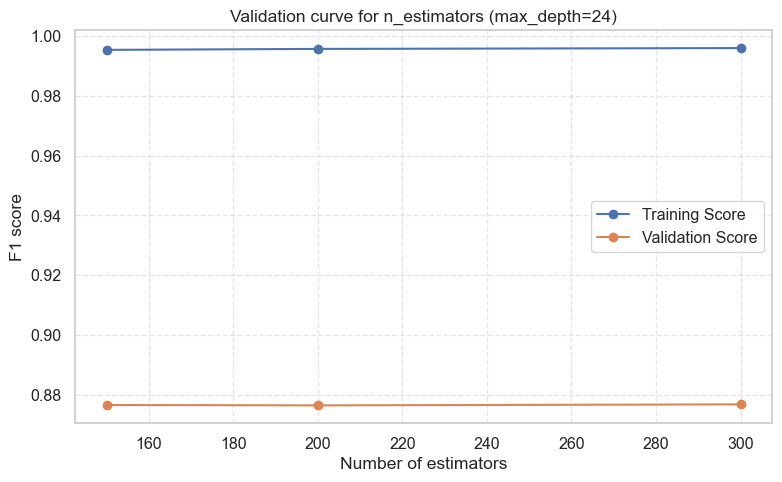

In [20]:
# Validation curve for n_estimators (F1 score)
import matplotlib.pyplot as plt

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_df = results
except NameError:
    # fall back to grid.cv_results_ if results is not defined
    cv_results_df = pd.DataFrame(grid.cv_results_)

# Filter to max_depth = 24 so we only look at that depth
target_max_depth = 24
cv_results_df_md24 = cv_results_df[cv_results_df["param_max_depth"] == target_max_depth]

# Group by n_estimators at the chosen max_depth
summary_n = (
    cv_results_df_md24
    .groupby("param_n_estimators")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_n_estimators")
)

print(f"\nF1 scores per n_estimators at max_depth={target_max_depth}:")
print(summary_n.to_string(index=False))

# Plot validation curve
plt.figure(figsize=(8, 5))
plt.plot(summary_n["param_n_estimators"], summary_n["mean_train_f1"], marker="o", label="Training Score")
plt.plot(summary_n["param_n_estimators"], summary_n["mean_val_f1"], marker="o", label="Validation Score")
plt.xlabel("Number of estimators")
plt.ylabel("F1 score")
plt.title(f"Validation curve for n_estimators (max_depth={target_max_depth})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Random Forest max_depth tuning summary (n_estimators=150):
 max_depth  Train F1  Validation F1
        24    0.9953         0.8766
        20    0.9879         0.8763
        16    0.9646         0.8752
        12    0.9299         0.8735
         8    0.8868         0.8682


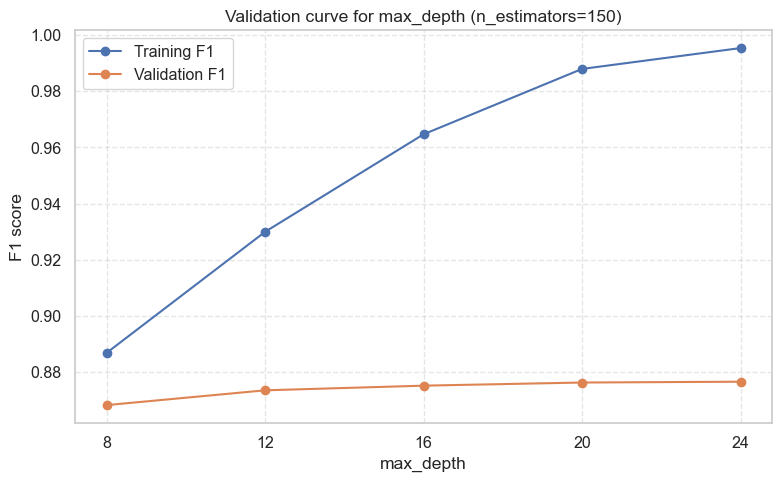

In [21]:
# Validation curve for max_depth (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_md = results
except NameError:
    cv_results_md = pd.DataFrame(grid.cv_results_)

# Restrict to a fixed number of estimators
target_n_estimators = 150
cv_results_md_n150 = cv_results_md[cv_results_md["param_n_estimators"] == target_n_estimators]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each max_depth at n_estimators = 150
# ---------------------------------------------------------------------------
summary_md = (
    cv_results_md_n150
    .groupby("param_max_depth")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
 )

summary_md_pretty = summary_md.rename(columns={
    "param_max_depth": "max_depth",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

# Sort by Validation F1 descending to see best depth first
summary_md_pretty = summary_md_pretty.sort_values("Validation F1", ascending=False).reset_index(drop=True)

print(f"\nRandom Forest max_depth tuning summary (n_estimators={target_n_estimators}):")
print(summary_md_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for max_depth
# ---------------------------------------------------------------------------
# Use positions on x-axis so we can include None as a label
x_pos = np.arange(len(summary_md))
train_f1_vals = summary_md["mean_train_f1"].values
val_f1_vals   = summary_md["mean_val_f1"].values
labels        = summary_md["param_max_depth"].astype(str).values

plt.figure(figsize=(8, 5))
plt.plot(x_pos, train_f1_vals, marker="o", label="Training F1")
plt.plot(x_pos, val_f1_vals, marker="o", label="Validation F1")
plt.xticks(x_pos, labels)
plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title(f"Validation curve for max_depth (n_estimators={target_n_estimators})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Random Forest min_samples_split tuning summary (max_depth=20, n_estimators=150):
 min_samples_split  Train F1  Validation F1
                 2    0.9905         0.8763
                 5    0.9854         0.8762


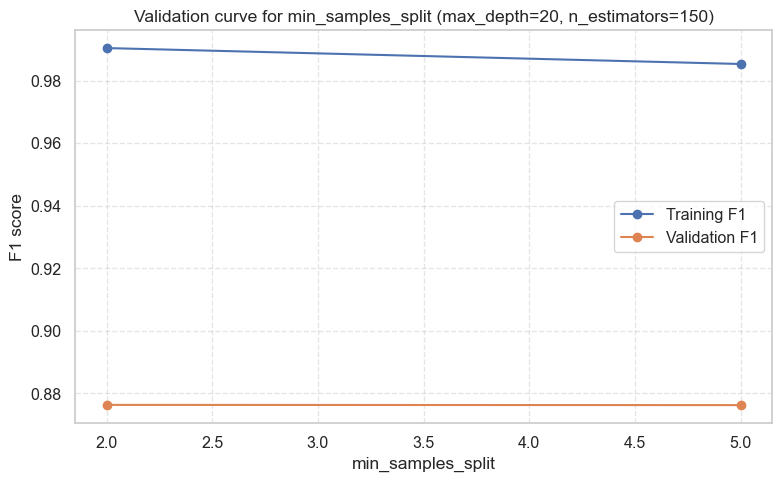

In [24]:
# Validation curve for min_samples_split (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_split = results
except NameError:
    cv_results_split = pd.DataFrame(grid.cv_results_)

# If min_samples_split was not part of the grid, warn and skip
if "param_min_samples_split" not in cv_results_split.columns:
    raise KeyError("param_min_samples_split is not in cv_results_. Add min_samples_split to param_grid in Cell 5.")

# Restrict to max_depth = 20 and n_estimators = 150
target_max_depth = 20
target_n_estimators = 150
cv_results_split_sel = cv_results_split[(
    (cv_results_split["param_max_depth"] == target_max_depth)
    & (cv_results_split["param_n_estimators"] == target_n_estimators)
)]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each min_samples_split at the chosen settings
# ---------------------------------------------------------------------------
summary_split = (
    cv_results_split_sel
    .groupby("param_min_samples_split")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_min_samples_split")
)

summary_split_pretty = summary_split.rename(columns={
    "param_min_samples_split": "min_samples_split",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

print(f"\nRandom Forest min_samples_split tuning summary (max_depth={target_max_depth}, n_estimators={target_n_estimators}):")
print(summary_split_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for min_samples_split
# ---------------------------------------------------------------------------
x_vals_split = summary_split["param_min_samples_split"].values
train_f1_vals_split = summary_split["mean_train_f1"].values
val_f1_vals_split   = summary_split["mean_val_f1"].values

plt.figure(figsize=(8, 5))
plt.plot(x_vals_split, train_f1_vals_split, marker="o", label="Training F1")
plt.plot(x_vals_split, val_f1_vals_split, marker="o", label="Validation F1")
plt.xlabel("min_samples_split")
plt.ylabel("F1 score")
plt.title(f"Validation curve for min_samples_split (max_depth={target_max_depth}, n_estimators={target_n_estimators})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Random Forest min_samples_leaf tuning summary (max_depth=20, n_estimators=150, min_samples_split=2):
 min_samples_leaf  Train F1  Validation F1
                1    0.9948         0.8762
                2    0.9861         0.8765


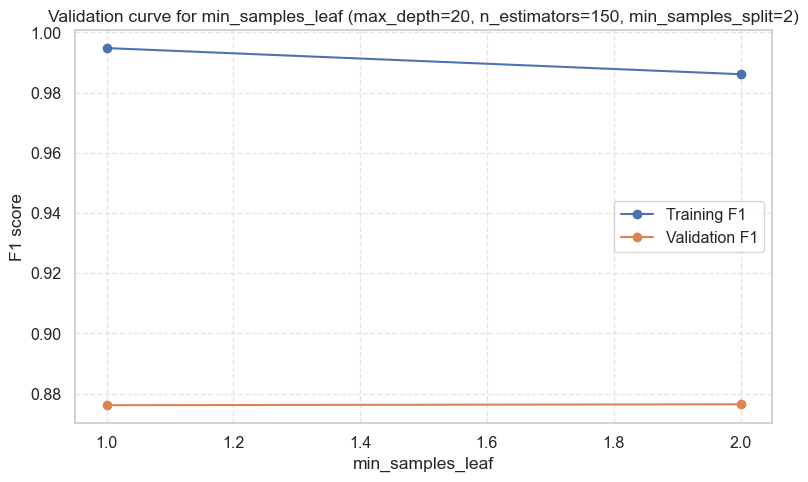

In [25]:
# Validation curve for min_samples_leaf (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_leaf = results
except NameError:
    cv_results_leaf = pd.DataFrame(grid.cv_results_)

# If min_samples_leaf was not part of the grid, warn and skip
if "param_min_samples_leaf" not in cv_results_leaf.columns:
    raise KeyError("param_min_samples_leaf is not in cv_results_. Add min_samples_leaf to param_grid in Cell 5.")

# Restrict to max_depth = 20, n_estimators = 150, and min_samples_split = 2
target_max_depth = 20
target_n_estimators = 150
target_min_samples_split = 2
cv_results_leaf_sel = cv_results_leaf[(
    (cv_results_leaf["param_max_depth"] == target_max_depth)
    & (cv_results_leaf["param_n_estimators"] == target_n_estimators)
    & (cv_results_leaf["param_min_samples_split"] == target_min_samples_split)
)]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each min_samples_leaf at the chosen settings
# ---------------------------------------------------------------------------
summary_leaf = (
    cv_results_leaf_sel
    .groupby("param_min_samples_leaf")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_min_samples_leaf")
)

summary_leaf_pretty = summary_leaf.rename(columns={
    "param_min_samples_leaf": "min_samples_leaf",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

print(f"\nRandom Forest min_samples_leaf tuning summary (max_depth={target_max_depth}, n_estimators={target_n_estimators}, min_samples_split={target_min_samples_split}):")
print(summary_leaf_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for min_samples_leaf
# ---------------------------------------------------------------------------
x_vals_leaf = summary_leaf["param_min_samples_leaf"].values
train_f1_vals_leaf = summary_leaf["mean_train_f1"].values
val_f1_vals_leaf   = summary_leaf["mean_val_f1"].values

plt.figure(figsize=(8, 5))
plt.plot(x_vals_leaf, train_f1_vals_leaf, marker="o", label="Training F1")
plt.plot(x_vals_leaf, val_f1_vals_leaf, marker="o", label="Validation F1")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1 score")
plt.title(f"Validation curve for min_samples_leaf (max_depth={target_max_depth}, n_estimators={target_n_estimators}, min_samples_split={target_min_samples_split})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
pip install numpy pandas scipy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import pandas as pd
import uwb_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

data = uwb_dataset.import_from_files()  # numpy array

# column names based on CSV format
base_cols = [
    "NLOS","RANGE","FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","CIR_PWR","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR"
]
cir_cols = [f"CIR{i}" for i in range(1016)]
cols = base_cols + cir_cols

df = pd.DataFrame(data, columns=cols)
df.head()

../dataset/uwb_dataset_part1.csv
../dataset/uwb_dataset_part2.csv
../dataset/uwb_dataset_part3.csv
../dataset/uwb_dataset_part4.csv
../dataset/uwb_dataset_part5.csv
../dataset/uwb_dataset_part6.csv
../dataset/uwb_dataset_part7.csv


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,0.456628,0.749591,0.299509,0.258592,0.324059,0.142390,0.484452,0.826514,0.502455,0.000000
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,0.322148,0.747204,0.648770,0.510067,0.418345,0.476510,0.451902,0.199105,0.230425,0.000000
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,0.044260,0.515906,0.309820,0.240664,0.171508,0.455048,0.286307,0.132780,0.301521,0.000000
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,0.246094,0.168945,0.193359,0.156250,0.423828,0.387695,0.283203,0.151367,0.333984,0.250000
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,0.557971,0.757246,0.876812,1.072464,0.315217,0.644928,1.137681,0.894928,1.057971,0.927536


In [9]:
WINDOW_SIZE = 200
LEAD        = 10  

cir_array  = df[cir_cols].to_numpy()
fp_indices = df["FP_IDX"].to_numpy().astype(int)

windowed = np.zeros((len(df), WINDOW_SIZE))

for i in range(len(df)):
    fp_idx = fp_indices[i]
    start  = max(0, fp_idx - LEAD)
    end    = min(1016, start + WINDOW_SIZE)
    actual_size               = end - start
    windowed[i, :actual_size] = cir_array[i, start:end]

df          = df.drop(columns=cir_cols)
cir_cols    = [f"CIR_{i}" for i in range(WINDOW_SIZE)]  
windowed_df = pd.DataFrame(windowed, columns=cir_cols, index=df.index)
df          = pd.concat([df, windowed_df], axis=1)

# Verify
print(f"Windowed array shape: {windowed.shape}")
print(f"New df shape: {df.shape}")
print(f"All zero rows: {(windowed == 0).all(axis=1).sum()}")


Windowed array shape: (42000, 200)
New df shape: (42000, 215)
All zero rows: 0


Basic Cleaning/Validation

In [10]:
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

#drop duplicates if any
df = df.drop_duplicates()

Missing values: 0
Duplicates: 0


This checks for outliers in the 10 raw base columns from the original dataset — the non-CIR signal/hardware metadata columns that exist before any feature engineering. No need to remove them as they are meaningful

Feature                  Q1         Q3        IQR      Lower      Upper   Outliers      %
--------------------------------------------------------------------------------------
RANGE                  1.81       5.42       3.61      -3.60      10.84        121   0.29%
FP_IDX               744.00     748.00       4.00     738.00     754.00      1,757   4.18%
FP_AMP1             3573.75   12273.00    8699.25   -9475.12   25321.88          0   0.00%
FP_AMP2             5322.75   17310.00   11987.25  -12658.12   35290.88          0   0.00%
FP_AMP3             4723.00   14256.00    9533.00   -9576.50   28555.50          0   0.00%
STDEV_NOISE           56.00      80.00      24.00      20.00     116.00      1,915   4.56%
CIR_PWR             6727.00   12443.00    5716.00   -1847.00   21017.00        938   2.23%
MAX_NOISE            961.00    1488.00     527.00     170.50    2278.50      2,965   7.06%
RXPACC               318.00    1024.00     706.00    -741.00    2083.00          0   0.00%


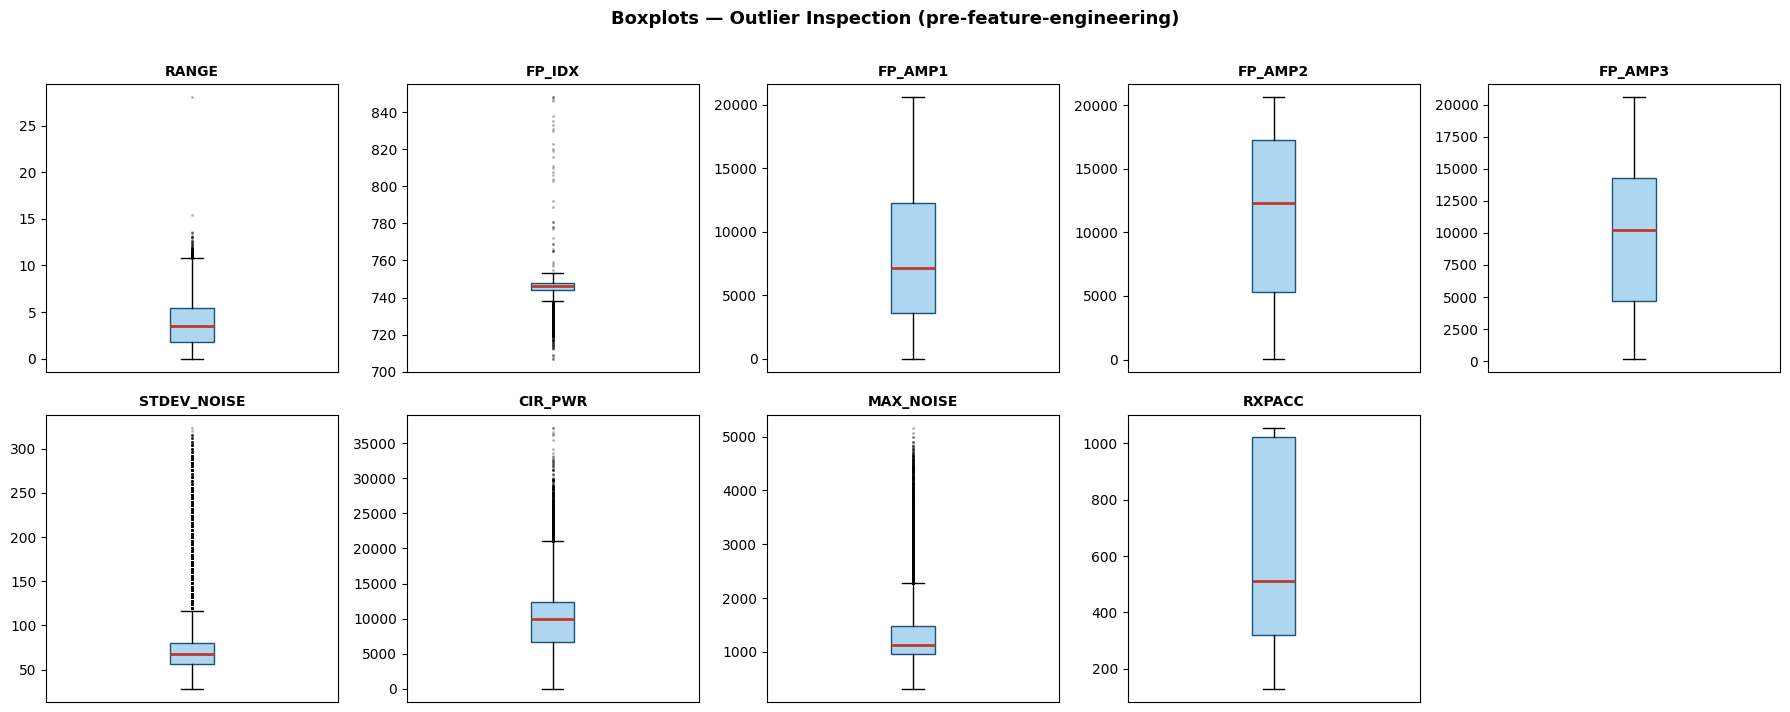

In [11]:

import matplotlib.pyplot as plt

numeric_cols = [
    "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC"
]

# ── IQR outlier count per feature ────────────────────────────────────────────
print(f"{'Feature':<16} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("-" * 86)
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = 100 * n_out / len(df)
    print(f"{col:<16} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} {lower:>10.2f} {upper:>10.2f} {n_out:>10,} {pct:>6.2f}%")

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
               medianprops=dict(color="#C0392B", linewidth=2),
               flierprops=dict(marker=".", markersize=2, alpha=0.3, color="#717D7E"))
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xticks([])

# hide unused subplot
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle("Boxplots — Outlier Inspection (pre-feature-engineering)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


feature engineering

In [12]:
from scipy.stats import kurtosis as sp_kurtosis

# FP "power" aggregate
df["FP_POWER"] = (df["FP_AMP1"]**2 + df["FP_AMP2"]**2 + df["FP_AMP3"]**2)

# Simple CIR summary stats (fast, useful)
cir = df[cir_cols].to_numpy()
df["CIR_MEAN"] = cir.mean(axis=1)
df["CIR_MAX"]  = cir.max(axis=1)
df["CIR_ENERGY"] = (cir**2).mean(axis=1)  # average energy

delays = np.arange(200)
power = cir ** 2
mean_delay = (delays * power).sum(axis=1) / power.sum(axis=1)
rms_ds = np.sqrt(((delays - mean_delay[:, None])**2 * power).sum(axis=1) /
power.sum(axis=1))
df["RMS_DELAY_SPREAD"] = rms_ds


df["FP_RSS"]  = 10 * np.log10(df["FP_POWER"]  / (df["RXPACC"]**2) + 1e-9)
df["CIR_RSS"] = 10 * np.log10(df["CIR_PWR"] * 2**17 / (df["RXPACC"]**2) + 1e-9)
df["FP_CIR_RATIO_dB"] = df["FP_RSS"] - df["CIR_RSS"]

# Rise time: distance from first path to CIR peak (NLOS → larger rise time)
peak_idx = np.argmax(cir, axis=1)
df["RISE_TIME"] = peak_idx - LEAD

# CIR kurtosis: LOS → sharp spike (high), NLOS → spread (low)
df["CIR_KURTOSIS"] = sp_kurtosis(cir, axis=1, fisher=True)

# Early-late energy ratio: NLOS has proportionally more late energy
mid = WINDOW_SIZE // 2
early_energy = (cir[:, :mid] ** 2).sum(axis=1)
late_energy  = (cir[:, mid:] ** 2).sum(axis=1)
df["EARLY_LATE_RATIO"] = 10 * np.log10(early_energy / (late_energy + 1e-9))

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR_MEAN,CIR_MAX,CIR_ENERGY,RMS_DELAY_SPREAD,FP_RSS,CIR_RSS,FP_CIR_RATIO_dB,RISE_TIME,CIR_KURTOSIS,EARLY_LATE_RATIO
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,1.799182,37.769231,21.908637,10.515277,31.981842,36.193291,-4.211449,3,26.633499,24.132437
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,3.228691,40.400447,71.715034,8.477951,29.744014,40.949164,-11.205150,8,11.717678,27.380500
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,2.293313,23.248963,20.051523,15.783530,20.490285,35.665211,-15.174926,8,9.062051,21.260522
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,0.986128,15.373047,5.804017,12.561988,22.293444,30.388188,-8.094743,6,18.135945,21.927425
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,3.542464,70.952899,101.726681,12.408521,40.165057,42.918340,-2.753284,4,26.988227,22.212076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,14948.0,96.0,9987.0,2379.0,276.0,...,4.292409,63.862319,89.635845,15.996894,39.662480,42.351268,-2.688788,2,20.204613,20.735319
41996,0.0,1.39,745.0,2235.0,15089.0,8796.0,76.0,12559.0,1810.0,281.0,...,4.477313,76.921708,111.767999,12.514075,35.940090,43.190523,-7.250434,5,22.388287,23.716913
41997,1.0,5.48,747.0,7115.0,6262.0,4584.0,72.0,1435.0,1092.0,1024.0,...,0.600718,5.769531,1.080732,33.372093,20.241316,22.537619,-2.296303,3,20.322855,11.998804
41998,1.0,3.40,745.0,6662.0,7683.0,5600.0,72.0,1491.0,1077.0,1024.0,...,0.480571,7.432617,1.081603,24.419823,21.089957,22.703877,-1.613920,1,28.872993,15.528570


Splitting of data into training and test set (80 : 20)

In [13]:
y_classification = df["NLOS"].astype(int).to_numpy()
y_regression = df["RANGE"].to_numpy()

non_cir_features = [
    "FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR",
    "CIR_MEAN","CIR_MAX","CIR_ENERGY", "RMS_DELAY_SPREAD","FP_RSS","CIR_RSS","FP_CIR_RATIO_dB",
    "RISE_TIME","CIR_KURTOSIS","EARLY_LATE_RATIO"
]

X_non_cir = df[non_cir_features].to_numpy()   # (42000, 22)
X_cir     = df[cir_cols].to_numpy()            # (42000, 200)
X_raw     = np.hstack([X_non_cir, X_cir])      # (42000, 222)

X_train_raw, X_test_raw, y_train, y_test, y_reg_train, y_reg_test = train_test_split(
      X_raw, y_classification, y_regression,
      test_size=0.2, random_state=42, stratify=y_classification
  )

print(f"Train: {X_train_raw.shape}")
print(f"Test:  {X_test_raw.shape}")
print(f"y_reg_train:  {y_reg_train.shape}")
print(f"y_reg_test:   {y_reg_test.shape}")

Train: (33600, 222)
Test:  (8400, 222)
y_reg_train:  (33600,)
y_reg_test:   (8400,)


Feature Importance Ranking (model-agnostic) (classification)

C:\Users\tjmbe\AppData\Local\Temp\ipykernel_14504\682443535.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs(spearmanr(X_fi[:, i], y_fi).statistic)


Rank  Feature               MI Score    Spearman |r|   RF Importance
1     CIR_ENERGY              0.3391          0.7268          0.1674
2     CIR_RSS                 0.3380          0.7269          0.1292
3     CIR_MAX                 0.3315          0.7125          0.1502
4     RXPACC                  0.3182          0.7063          0.1199
5     CIR_MEAN                0.3125          0.7051          0.0944
6     FP_RSS                  0.3122          0.6938          0.0966
7     EARLY_LATE_RATIO        0.2087          0.5438          0.0421
8     RMS_DELAY_SPREAD        0.1872          0.5290          0.0458
9     FP_AMP3                 0.1570          0.5098          0.0254
10    FP_AMP2                 0.1546          0.5139          0.0236
11    MAX_NOISE               0.1419          0.1790          0.0269
12    FP_AMP1                 0.1133          0.4516          0.0134
13    FP_IDX                  0.1002          0.3456          0.0080
14    FP_CIR_RATIO_dB         0.09

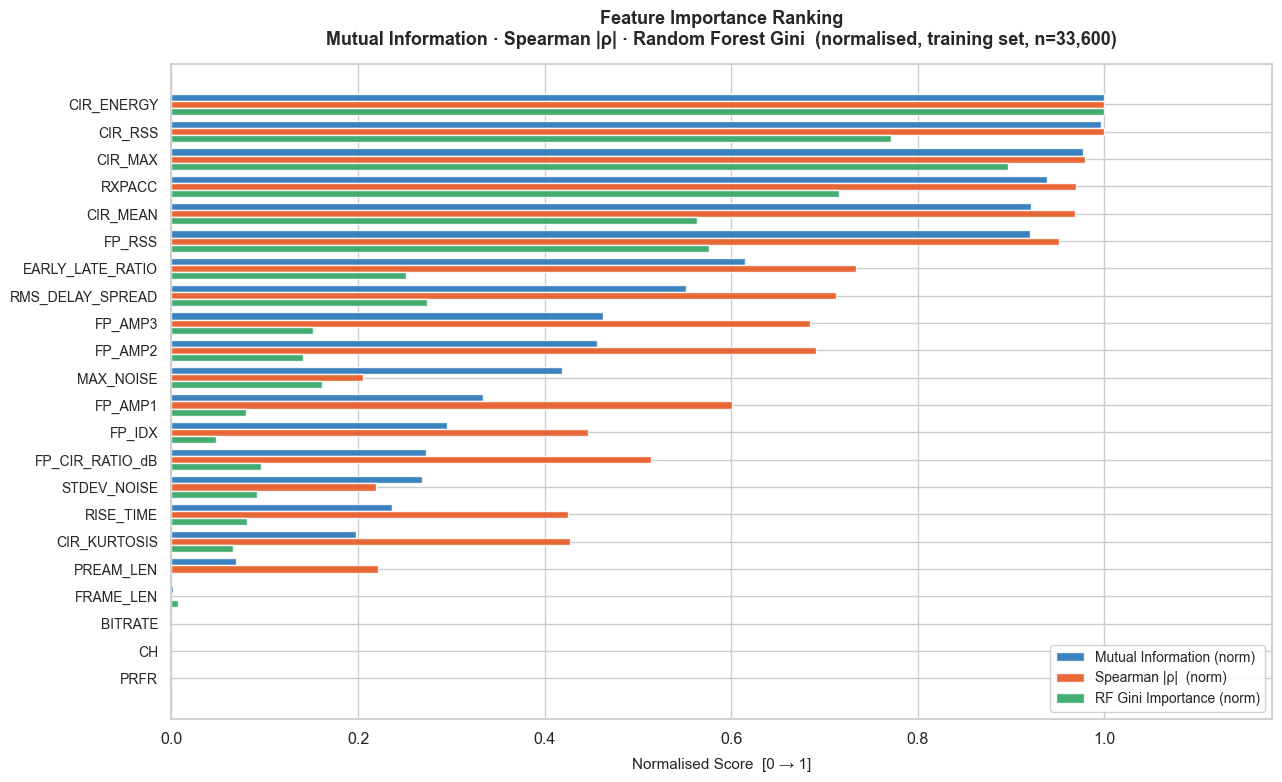

In [14]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

n_non_cir = len(non_cir_features)

# Training set only — never touch test data during preprocessing decisions
X_fi = X_train_raw[:, :n_non_cir]
y_fi = y_train

# ── 1. Mutual Information ──────────────────────────────────────────────────────
# Discrete hardware-config features must use the exact discrete entropy estimator,
# not the kNN continuous estimator (which inflates MI for low-cardinality features).
discrete_features_set = {"CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"}
discrete_mask = [f in discrete_features_set for f in non_cir_features]

mi_scores = mutual_info_classif(
    X_fi, y_fi, discrete_features=discrete_mask, random_state=42, n_neighbors=5
)

# ── 2. Spearman |ρ| ────────────────────────────────────────────────────────────
# Captures monotonic relationships — scale-invariant cross-check.
# spearmanr returns NaN for constant/near-constant features; we keep those as NaN
# so they don't corrupt normalization for other features.
spearman_r = np.array([
    abs(spearmanr(X_fi[:, i], y_fi).statistic)
    for i in range(X_fi.shape[1])
], dtype=float)

# ── 3. Random Forest Gini Importance ──────────────────────────────────────────
# Shallow forest — purpose is ranking only, NOT final model selection
rf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_fi, y_fi)
rf_importance = rf.feature_importances_

# ── 4. Normalise all three to [0, 1] for fair visual comparison ───────────────
# nanmin/nanmax so that NaN entries in spearman_r don't corrupt the whole array.
def norm(arr):
    arr = np.asarray(arr, dtype=float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# ── 5. Ranked DataFrame (primary sort: MI Score) ──────────────────────────────
fi_df = (
    pd.DataFrame({
        "Feature"        : non_cir_features,
        "MI Score"       : mi_scores,
        "Spearman |r|"   : spearman_r,
        "RF Importance"  : rf_importance,
        "MI (norm)"      : norm(mi_scores),
        "Spearman (norm)": norm(spearman_r),
        "RF (norm)"      : norm(rf_importance),
    })
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
fi_df.index += 1  # 1-based rank

# ── 6. Print ranked table ─────────────────────────────────────────────────────
print("=" * 74)
print(f"{'Rank':<6}{'Feature':<18}{'MI Score':>12}{'Spearman |r|':>16}{'RF Importance':>16}")
print("=" * 74)
for rank, row in fi_df.iterrows():
    sp = f"{row['Spearman |r|']:>16.4f}" if not np.isnan(row['Spearman |r|']) else f"{'—':>16}"
    print(f"{rank:<6}{row['Feature']:<18}{row['MI Score']:>12.4f}{sp}{row['RF Importance']:>16.4f}")
print("=" * 74)

# ── 7. Grouped bar chart — all three metrics normalised to [0, 1] ─────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

features_sorted = fi_df["Feature"].tolist()[::-1]
mi_norm  = fi_df["MI (norm)"].tolist()[::-1]
sp_norm  = fi_df["Spearman (norm)"].tolist()[::-1]
rf_norm  = fi_df["RF (norm)"].tolist()[::-1]

y_pos  = np.arange(len(fi_df))
h      = 0.26  # bar height

ax.barh(y_pos + h,  mi_norm, h, color="#2171B5", alpha=0.88, label="Mutual Information (norm)")
ax.barh(y_pos,      sp_norm, h, color="#E8541E", alpha=0.88, label="Spearman |ρ|  (norm)")
ax.barh(y_pos - h,  rf_norm, h, color="#2CA25F", alpha=0.88, label="RF Gini Importance (norm)")

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel("Normalised Score  [0 → 1]", fontsize=11, labelpad=8)
ax.set_xlim(0, 1.18)
ax.set_title(
    "Feature Importance Ranking\n"
    "Mutual Information · Spearman |ρ| · Random Forest Gini  "
    f"(normalised, training set, n={len(X_fi):,})",
    fontsize=13, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", framealpha=0.88, fontsize=10)

plt.tight_layout()
plt.show()


Feature Importance Ranking (Regression — RANGE target)

C:\Users\tjmbe\AppData\Local\Temp\ipykernel_14504\1770433424.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs(spearmanr(X_fi[:, i], y_fi_reg).statistic)


Rank  Feature               MI Score    Spearman |r|   RF Importance
1     CIR_ENERGY              0.4211          0.6867          0.0147
2     CIR_RSS                 0.4087          0.6877          0.0861
3     CIR_MAX                 0.3789          0.6944          0.4777
4     RXPACC                  0.3779          0.6916          0.0625
5     FP_RSS                  0.3534          0.6706          0.0150
6     CIR_MEAN                0.3315          0.5686          0.0729
7     RMS_DELAY_SPREAD        0.2383          0.5771          0.0862
8     MAX_NOISE               0.2120          0.2558          0.0155
9     EARLY_LATE_RATIO        0.1960          0.5221          0.0098
10    CIR_KURTOSIS            0.1728          0.4090          0.0482
11    FP_AMP1                 0.1518          0.4656          0.0058
12    FP_AMP2                 0.1517          0.4716          0.0045
13    FP_AMP3                 0.1364          0.4476          0.0049
14    FP_CIR_RATIO_dB         0.12

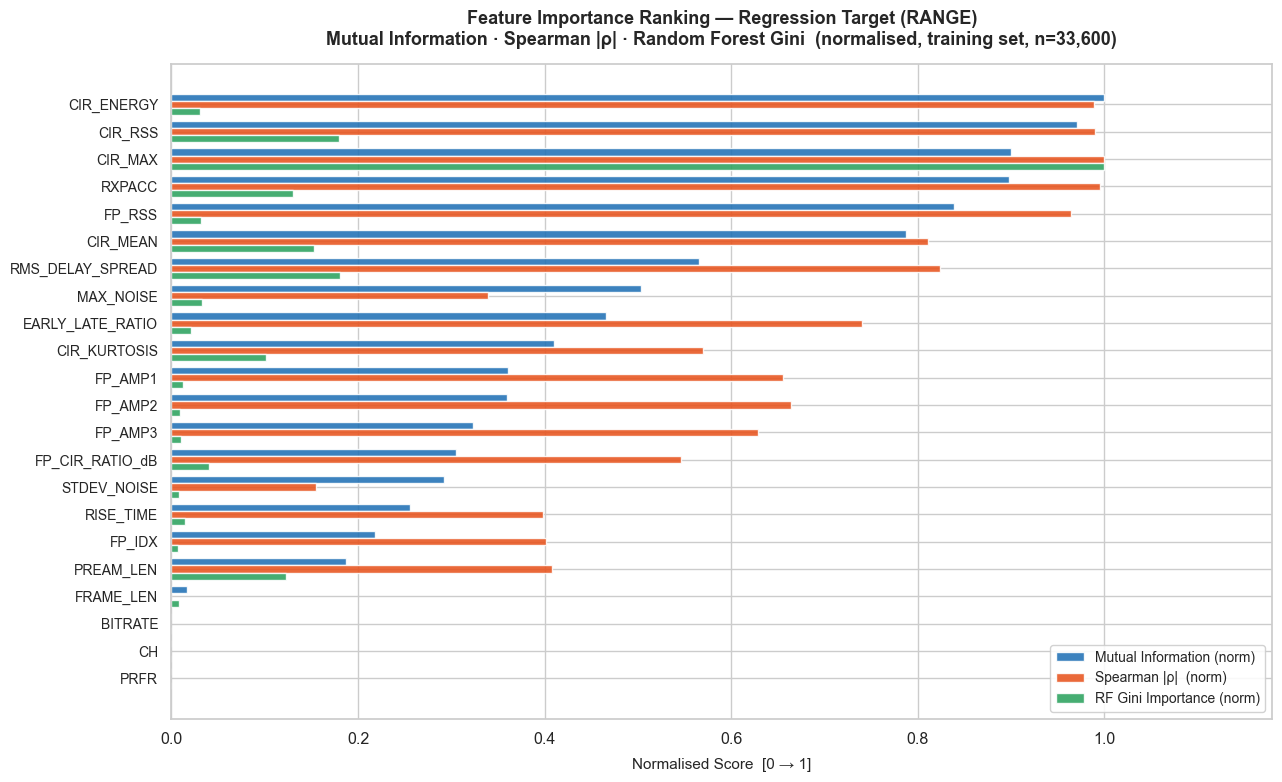

In [15]:

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

n_non_cir = len(non_cir_features)

X_fi = X_train_raw[:, :n_non_cir]
y_fi_reg = y_reg_train

# Same discrete mask as the classification cell
discrete_features_set = {"CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"}
discrete_mask = np.array([f in discrete_features_set for f in non_cir_features], dtype=bool)

# ── 1. Mutual Information (regression) ────────────────────────────────────────
mi_scores_reg = mutual_info_regression(
    X_fi, y_fi_reg, discrete_features=discrete_mask, random_state=42, n_neighbors=5
)

# ── 2. Spearman |ρ| ────────────────────────────────────────────────────────────
spearman_r_reg = np.array([
    abs(spearmanr(X_fi[:, i], y_fi_reg).statistic)
    for i in range(X_fi.shape[1])
], dtype=float)

# ── 3. Random Forest Gini Importance (regression) ─────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf_reg.fit(X_fi, y_fi_reg)
rf_importance_reg = rf_reg.feature_importances_

# ── 4. NaN-safe normalisation ─────────────────────────────────────────────────
def norm(arr):
    arr = np.asarray(arr, dtype=float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# ── 5. Ranked DataFrame (primary sort: MI Score) ──────────────────────────────
fi_reg_df = (
    pd.DataFrame({
        "Feature"        : non_cir_features,
        "MI Score"       : mi_scores_reg,
        "Spearman |r|"   : spearman_r_reg,
        "RF Importance"  : rf_importance_reg,
        "MI (norm)"      : norm(mi_scores_reg),
        "Spearman (norm)": norm(spearman_r_reg),
        "RF (norm)"      : norm(rf_importance_reg),
    })
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
fi_reg_df.index += 1  # 1-based rank

# ── 6. Print ranked table ─────────────────────────────────────────────────────
print("=" * 74)
print(f"{'Rank':<6}{'Feature':<18}{'MI Score':>12}{'Spearman |r|':>16}{'RF Importance':>16}")
print("=" * 74)
for rank, row in fi_reg_df.iterrows():
    sp = f"{row['Spearman |r|']:>16.4f}" if not np.isnan(row['Spearman |r|']) else f"{'—':>16}"
    print(f"{rank:<6}{row['Feature']:<18}{row['MI Score']:>12.4f}{sp}{row['RF Importance']:>16.4f}")
print("=" * 74)

# ── 7. Grouped bar chart ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

features_sorted = fi_reg_df["Feature"].tolist()[::-1]
mi_norm  = fi_reg_df["MI (norm)"].tolist()[::-1]
sp_norm  = fi_reg_df["Spearman (norm)"].tolist()[::-1]
rf_norm  = fi_reg_df["RF (norm)"].tolist()[::-1]

y_pos = np.arange(len(fi_reg_df))
h     = 0.26

ax.barh(y_pos + h, mi_norm, h, color="#2171B5", alpha=0.88, label="Mutual Information (norm)")
ax.barh(y_pos,     sp_norm, h, color="#E8541E", alpha=0.88, label="Spearman |ρ|  (norm)")
ax.barh(y_pos - h, rf_norm, h, color="#2CA25F", alpha=0.88, label="RF Gini Importance (norm)")

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel("Normalised Score  [0 → 1]", fontsize=11, labelpad=8)
ax.set_xlim(0, 1.18)
ax.set_title(
    "Feature Importance Ranking — Regression Target (RANGE)\n"
    "Mutual Information · Spearman |ρ| · Random Forest Gini  "
    f"(normalised, training set, n={len(X_fi):,})",
    fontsize=13, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", framealpha=0.88, fontsize=10)

plt.tight_layout()
plt.show()


PCA for CIR component of training and test set

In [16]:
from sklearn.compose import ColumnTransformer

drop_features = ["FRAME_LEN", "CH", "BITRATE", "PRFR", "PREAM_LEN", "STDEV_NOISE"]

selected_features = [f for f in non_cir_features if f not in drop_features]

X_non_cir = df[selected_features].to_numpy()
X_raw     = np.hstack([X_non_cir, X_cir])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

n = len(selected_features)
non_cir_idx = list(range(n))                          # auto-adjusts
cir_idx     = list(range(n, n + WINDOW_SIZE))

preprocessor = ColumnTransformer([
    ('non_cir', StandardScaler(), non_cir_idx),
    ('cir', Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=86, random_state=42))
    ]), cir_idx)
])

X_train_classification = preprocessor.fit_transform(X_train_raw)  
X_test_classification  = preprocessor.transform(X_test_raw)         

print(f"X_train_classification: {X_train_classification.shape}")  
print(f"X_test_classification:  {X_test_classification.shape}")    
print("Explained variance:", preprocessor.named_transformers_['cir']['pca'].explained_variance_ratio_.sum())

X_train_classification: (33600, 102)
X_test_classification:  (8400, 102)
Explained variance: 0.8027736129314542


Random Forest Number 1


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'max_depth': 24, 'n_estimators': 150}
Best CV F1 score: 0.8768840956045413
Test accuracy:  0.8791666666666667

              precision    recall  f1-score   support

         LOS       0.85      0.91      0.88      4200
        NLOS       0.91      0.84      0.87      4200

    accuracy                           0.88      8400
   macro avg       0.88      0.88      0.88      8400
weighted avg       0.88      0.88      0.88      8400



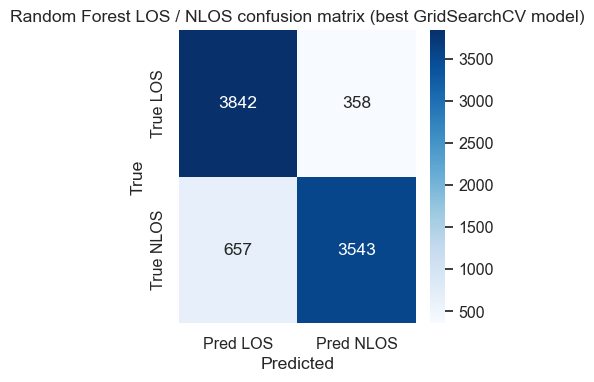

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Random Forest LOS / NLOS classifier with GridSearchCV ----
# Base estimator (class-balanced due to LOS/NLOS imbalance)
base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

# Small hyperparameter grid for depth and number of trees
param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [None, 12, 24],
}

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_classification, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

# Use the best found Random Forest for evaluation
rf_clf = grid_search.best_estimator_

y_pred  = rf_clf.predict(X_test_classification)
y_proba = rf_clf.predict_proba(X_test_classification)[:, 1]  # P(NLOS)

print("Test accuracy: ", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["LOS", "NLOS"]))

# Confusion matrix (LOS vs NLOS)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred LOS", "Pred NLOS"],
            yticklabels=["True LOS", "True NLOS"])
plt.title("Random Forest LOS / NLOS confusion matrix (best GridSearchCV model)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

DATA PROCESSING FOR REGRESSION MODELS

Random Forest Test


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'max_depth': 24, 'n_estimators': 200}
Best CV F1 score: 0.8773222292580206
Test accuracy:  0.8789285714285714

              precision    recall  f1-score   support

         LOS       0.85      0.91      0.88      4200
        NLOS       0.91      0.84      0.87      4200

    accuracy                           0.88      8400
   macro avg       0.88      0.88      0.88      8400
weighted avg       0.88      0.88      0.88      8400



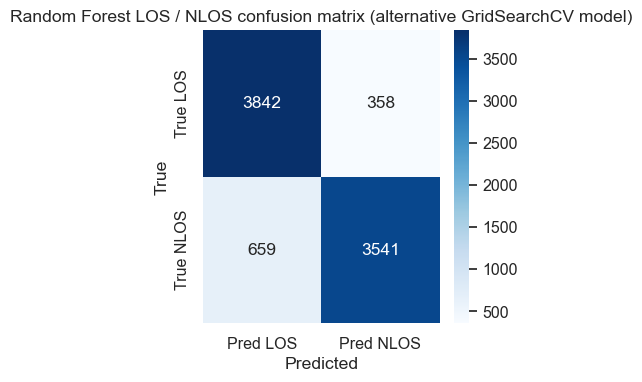

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Random Forest LOS / NLOS classifier with GridSearchCV (alternative settings) ----
# Base estimator (class-balanced due to LOS/NLOS imbalance)
base_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=24,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

# Same hyperparameters as Random Forest Number 1, but with different value ranges
param_grid = {
    "n_estimators": [150, 200, 300],
    "max_depth": [8, 12, 16, 20, 24, None],
}

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_classification, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

# Use the best found Random Forest for evaluation
rf_clf = grid_search.best_estimator_

y_pred  = rf_clf.predict(X_test_classification)
y_proba = rf_clf.predict_proba(X_test_classification)[:, 1]  # P(NLOS)

print("Test accuracy: ", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["LOS", "NLOS"]))

# Confusion matrix (LOS vs NLOS)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred LOS", "Pred NLOS"],
            yticklabels=["True LOS", "True NLOS"])
plt.title("Random Forest LOS / NLOS confusion matrix (alternative GridSearchCV model)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [30]:
X_train_reg = np.hstack([X_train_classification, y_train.reshape(-1, 1)]) #appends NLOS back
X_test_reg = np.hstack([X_test_classification, y_test.reshape(-1, 1)]) #appends NLOS back

print(f"X_train_reg:  {X_train_reg.shape}")   # (33600, 103)
print(f"X_test_reg:  {X_test_reg.shape}")   # (8400, 103)
print(f"y_reg_train:  {y_reg_train.shape}")    # (33600,)
print(f"y_reg_test:   {y_reg_test.shape}")     # (8400,)


X_train_reg:  (33600, 103)
X_test_reg:  (8400, 103)
y_reg_train:  (33600,)
y_reg_test:   (8400,)
